In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa as lib
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import os

# GPU Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Using: {device}")

Using: cuda


Noisy Time-Series (29331,)
Clean Time-Series (29331,)


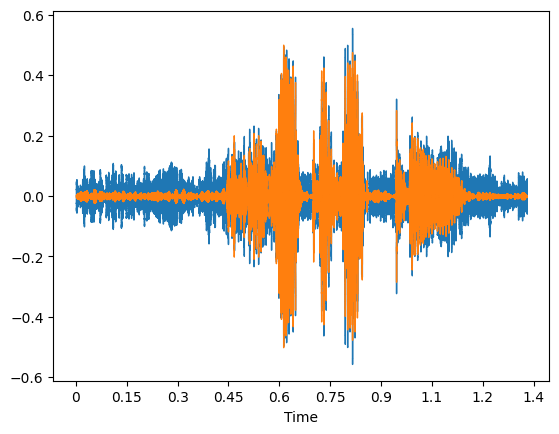

In [5]:

rootPath = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset"

clean_training_set = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset\clean_trainset_28spk_wav"
noisy_training_set = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset\noisy_trainset_28spk_wav"
clean_test_set     = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset\clean_testset_wav"
noisy_test_set     = r"C:\Users\dell\Downloads\FYP DENOIZER\Voice bank dataset\noisy_testset_wav"

# os.listdir(noisy_training_set)

# noisy_training_files = np.array([f for f in os.listdir(noisy_training_set)])
# clean_training_files = np.array([f for f in os.listdir(clean_training_set)])

# print(noisy_training_files.dtype)

# print(f"noisy training count {len(noisy_training_files)}")
# print(f"clean training count {len(clean_training_files)}")

yN, srN = lib.load(noisy_training_set+"/p287_386.wav", mono=True, sr=16000)
yC, srC = lib.load(clean_training_set+"/p287_386.wav", mono=True, sr=16000,)
print("Noisy Time-Series",yN.shape)
print("Clean Time-Series",yC.shape)
lib.display.waveshow(yN)
lib.display.waveshow(yC)




#loading all the files to librosa


# Exploratory Data Analysis (EDA)

Let's explore the dataset to understand the characteristics of the noisy and clean audio files. We'll look at their waveforms, spectrograms, and listen to a few examples.

Sample rate of noisy audio: 48000
Sample rate of clean audio: 48000
Noisy audio duration: 2.28 seconds
Clean audio duration: 2.28 seconds


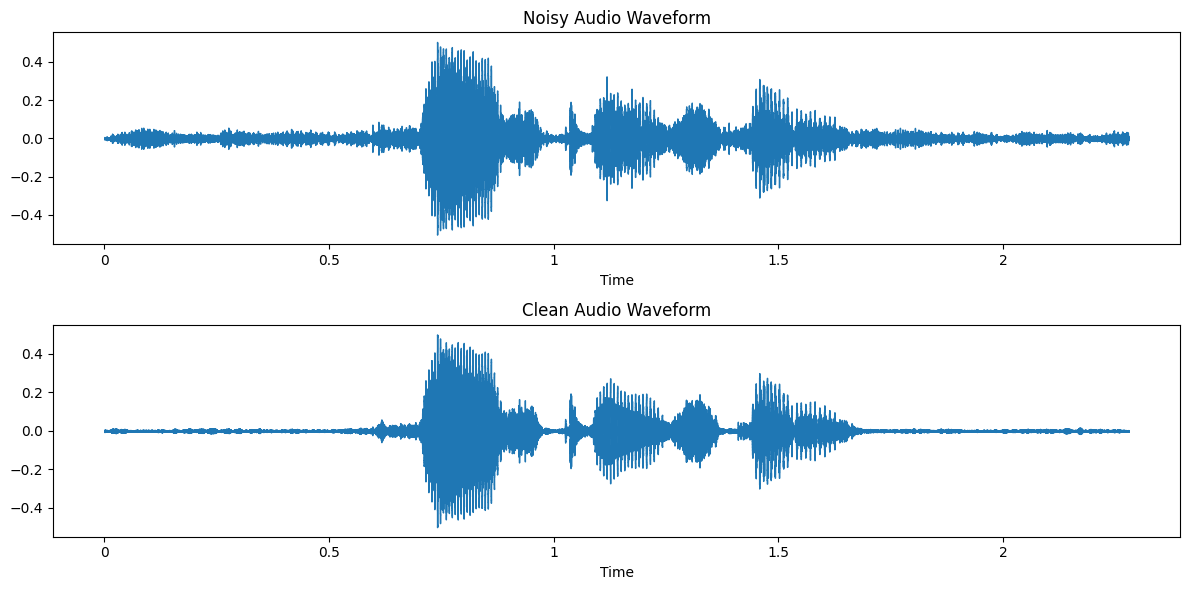

In [3]:
# 1. Load a sample noisy and clean audio file
sample_noisy_file = os.path.join(noisy_training_set, os.listdir(noisy_training_set)[0])
sample_clean_file = os.path.join(clean_training_set, os.listdir(clean_training_set)[0])

noisy_wav, sr_noisy = lib.load(sample_noisy_file, sr=None)
clean_wav, sr_clean = lib.load(sample_clean_file, sr=None)

print(f"Sample rate of noisy audio: {sr_noisy}")
print(f"Sample rate of clean audio: {sr_clean}")
print(f"Noisy audio duration: {len(noisy_wav)/sr_noisy:.2f} seconds")
print(f"Clean audio duration: {len(clean_wav)/sr_clean:.2f} seconds")

# 2. Waveform Visualization
fig, ax = plt.subplots(nrows=2, figsize=(12, 6))
lib.display.waveshow(noisy_wav, sr=sr_noisy, ax=ax[0])
ax[0].set_title('Noisy Audio Waveform')
lib.display.waveshow(clean_wav, sr=sr_clean, ax=ax[1])
ax[1].set_title('Clean Audio Waveform')
plt.tight_layout()
plt.show()

### 3. Spectrogram Visualization

Spectrograms show the frequency content of the audio over time.

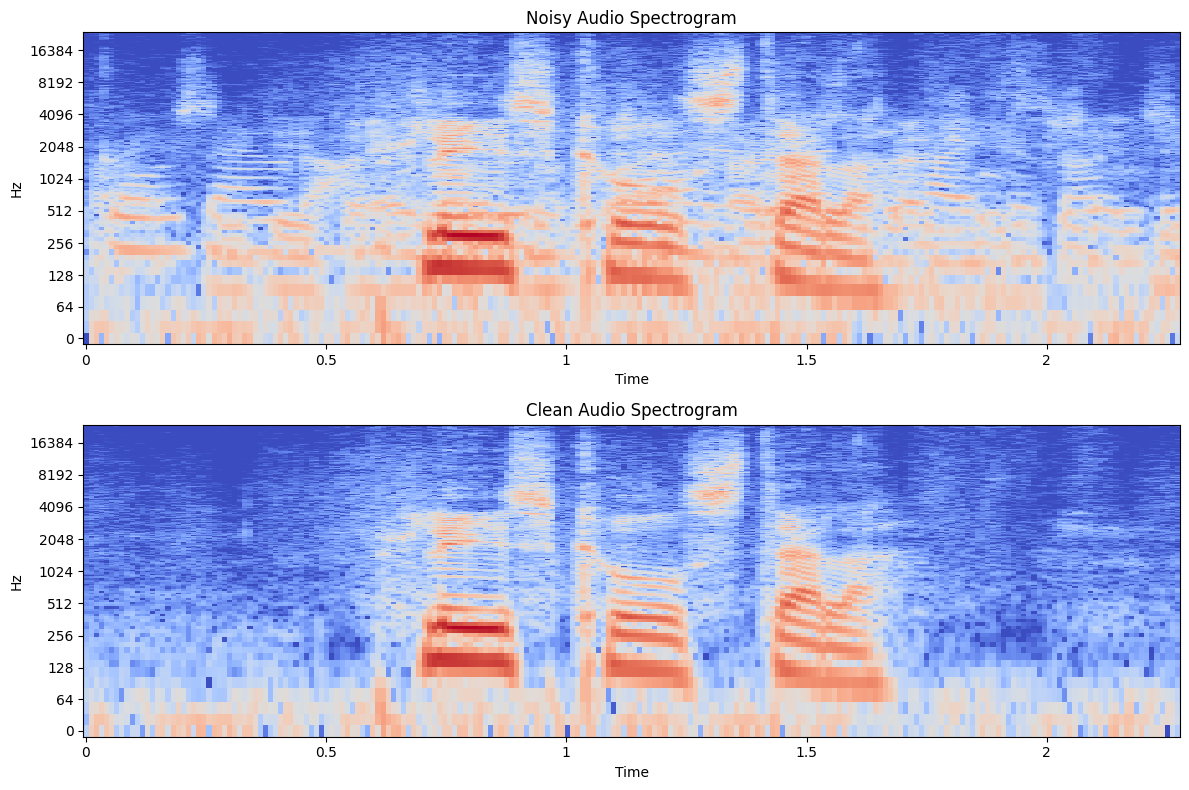

In [4]:
noisy_stft = lib.stft(noisy_wav)
clean_stft = lib.stft(clean_wav)

noisy_db = lib.amplitude_to_db(abs(noisy_stft))
clean_db = lib.amplitude_to_db(abs(clean_stft))

fig, ax = plt.subplots(nrows=2, figsize=(12, 8))
lib.display.specshow(noisy_db, sr=sr_noisy, x_axis='time', y_axis='log', ax=ax[0])
ax[0].set_title('Noisy Audio Spectrogram')
lib.display.specshow(clean_db, sr=sr_clean, x_axis='time', y_axis='log', ax=ax[1])
ax[1].set_title('Clean Audio Spectrogram')
plt.tight_layout()
plt.show()

STFT Parameters & Helper Functions

In [6]:

SAMPLE_RATE = 16000
FFT_SIZE = 512
HOP_LENGTH = 256
WINDOW_TYPE = "hann"
EPSILON = 1e-8


#defining window
def create_window(window_type: str, window_length: int):
    if window_type == "hann":
        return np.hanning(window_length)
    else:
        raise ValueError("Only Hann window is supported for consistency.")


#Frame_waveform
def frame_waveform(waveform, frame_length, hop_length):
    num_frames = 1 + (len(waveform) - frame_length) // hop_length
    frames = np.zeros((num_frames, frame_length))

    for i in range(num_frames):
        start = i * hop_length
        end = start + frame_length
        frames[i] = waveform[start:end]

    return frames

#STFT
def compute_stft(waveform):
    window = create_window(WINDOW_TYPE, FFT_SIZE)

    frames = frame_waveform(
        waveform,
        frame_length=FFT_SIZE,
        hop_length=HOP_LENGTH
    )

    # Apply window
    frames_windowed = frames * window

    # FFT (keep positive frequencies only)
    stft_matrix = np.fft.rfft(frames_windowed, n=FFT_SIZE, axis=1)

    # Transpose to (freq_bins, time_frames)
    stft_matrix = stft_matrix.T

    magnitude = np.abs(stft_matrix)
    phase = np.angle(stft_matrix)

    return magnitude, phase

#logMagnitude
def log_magnitude(magnitude):
    return np.log(magnitude + EPSILON)


def inverse_log_magnitude(log_mag):
    return np.exp(log_mag) - EPSILON


#Padd or crop
def pad_or_crop(spec, target_frames):
    freq_bins, time_frames = spec.shape

    if time_frames < target_frames:
        pad_width = target_frames - time_frames
        padding = np.zeros((freq_bins, pad_width))
        spec = np.concatenate([spec, padding], axis=1)

    elif time_frames > target_frames:
        spec = spec[:, :target_frames]

    return spec

#Preprocessing pipeline
def preprocess_audio(waveform, target_frames):
    magnitude, phase = compute_stft(waveform)

    log_mag = log_magnitude(magnitude)
    log_mag_fixed = pad_or_crop(log_mag, target_frames)

    # Add channel dimension for CNNs: (1, freq_bins, time_frames)
    model_input = log_mag_fixed[np.newaxis, :, :]

    return model_input, phase

#ISTFT Reconstruction
def compute_istft(magnitude, phase):
    window = create_window(WINDOW_TYPE, FFT_SIZE)

    # Recombine magnitude and phase
    complex_spec = magnitude * np.exp(1j * phase)

    # Inverse FFT
    frames = np.fft.irfft(complex_spec, n=FFT_SIZE, axis=0)

    num_frames = frames.shape[1]
    output_length = FFT_SIZE + (num_frames - 1) * HOP_LENGTH
    waveform = np.zeros(output_length)
    window_sum = np.zeros(output_length)

    for i in range(num_frames):
        start = i * HOP_LENGTH
        end = start + FFT_SIZE

        waveform[start:end] += frames[:, i] * window
        window_sum[start:end] += window ** 2

    # Normalize to avoid amplitude distortion
    nonzero_indices = window_sum > EPSILON
    waveform[nonzero_indices] /= window_sum[nonzero_indices]

    return waveform




Initial Validation

In [6]:
mag, phase = compute_stft(yN)

print("Magnitude shape:", mag.shape)
print("Phase shape:", phase.shape)


Magnitude shape: (257, 113)
Phase shape: (257, 113)


In [7]:
log_mag = log_magnitude(mag)

print("Log-mag min:", log_mag.min())
print("Log-mag max:", log_mag.max())


Log-mag min: -15.404319852632428
Log-mag max: 3.0022338544977303


In [8]:
TARGET_FRAMES = 256

model_input, phase = preprocess_audio(yN, TARGET_FRAMES)

print("Model input shape:", model_input.shape)


Model input shape: (1, 257, 256)


In [9]:
reconstructed = compute_istft(mag, phase)

print("Original length:", len(yN))
print("Reconstructed length:", len(reconstructed))


Original length: 29331
Reconstructed length: 29184


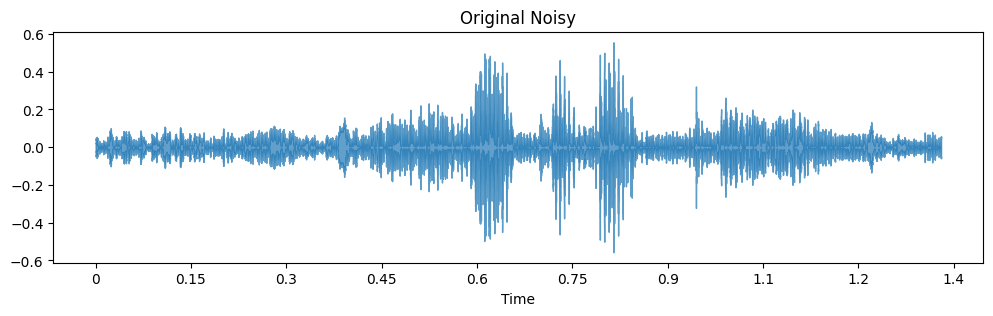

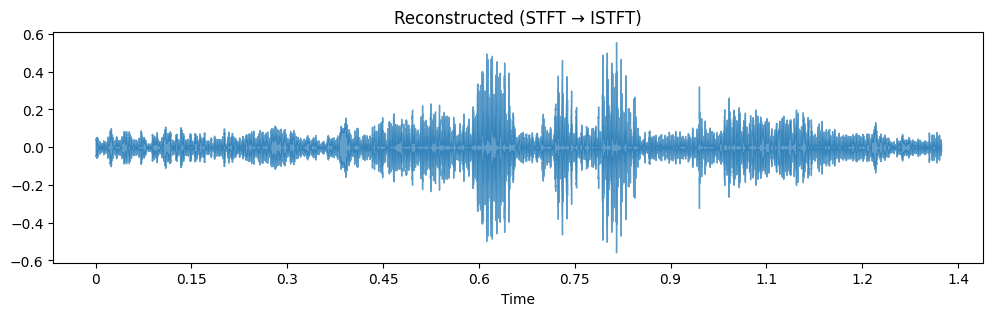

In [10]:
plt.figure(figsize=(12, 3))
lib.display.waveshow(yN, alpha=0.7)
plt.title("Original Noisy")
plt.show()

plt.figure(figsize=(12, 3))
lib.display.waveshow(reconstructed, alpha=0.7)
plt.title("Reconstructed (STFT → ISTFT)")
plt.show()


In [11]:
min_len = min(len(yN), len(reconstructed))
mse = np.mean((yN[:min_len] - reconstructed[:min_len])**2)
print("Reconstruction MSE:", mse)


Reconstruction MSE: 4.490332128956239e-08


Dataset Class


In [14]:
class SpeechEnhancementDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, target_frames, sample_rate=16000):
        self.target_frames = target_frames
        self.sample_rate = sample_rate
        self.filenames = sorted(os.listdir(noisy_dir))

        print("Preloading dataset into RAM...")
        self.data = []
        for fname in tqdm(self.filenames):
            noisy, _ = lib.load(os.path.join(noisy_dir, fname), sr=sample_rate, mono=True)
            clean, _ = lib.load(os.path.join(clean_dir, fname), sr=sample_rate, mono=True)
            noisy_input, _ = preprocess_audio(noisy, target_frames)
            clean_input, _ = preprocess_audio(clean, target_frames)
            # ← Fixed
            noisy_tensor = torch.tensor(noisy_input).float()
            clean_tensor = torch.tensor(clean_input).float()
            self.data.append((noisy_tensor, clean_tensor))
        print(f" Loaded {len(self.data)} samples into RAM")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [15]:
from torch.utils.data import random_split

full_dataset = SpeechEnhancementDataset(
    noisy_dir=noisy_training_set,
    clean_dir=clean_training_set,
    target_frames=256
)

# Split the dataset into training and validation sets
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Full dataset size: {len(full_dataset)}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

x, y = train_dataset[0]
print("Train sample shapes:", x.shape, y.shape)

vx, vy = val_dataset[0]
print("Validation sample shapes:", vx.shape, vy.shape)

Preloading dataset into RAM...


  0%|          | 0/11572 [00:00<?, ?it/s]

100%|██████████| 11572/11572 [07:05<00:00, 27.22it/s]


 Loaded 11572 samples into RAM
Full dataset size: 11572
Train dataset size: 10414
Validation dataset size: 1158
Train sample shapes: torch.Size([1, 257, 256]) torch.Size([1, 257, 256])
Validation sample shapes: torch.Size([1, 257, 256]) torch.Size([1, 257, 256])


In [16]:
BATCH_SIZE = 16

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)    
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0) 

print(f"Total training batches: {len(train_loader)}")
print(f"Total validation batches: {len(val_loader)}")

Total training batches: 650
Total validation batches: 73


In [17]:
noisy_batch, clean_batch = next(iter(train_loader))

print(noisy_batch.shape)
print(clean_batch.shape)


torch.Size([16, 1, 257, 256])
torch.Size([16, 1, 257, 256])


In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNetSpeechEnhancement(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 16, dropout_rate)
        self.enc2 = ConvBlock(16, 32, dropout_rate)
        self.enc3 = ConvBlock(32, 64, dropout_rate)
        self.enc4 = ConvBlock(64, 128, dropout_rate)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck (higher dropout at bottleneck)
        self.bottleneck = ConvBlock(128, 256, dropout_rate * 2)

        # Decoder
        self.dec4 = ConvBlock(256 + 128, 128, dropout_rate)
        self.dec3 = ConvBlock(128 + 64, 64, dropout_rate)
        self.dec2 = ConvBlock(64 + 32, 32, dropout_rate)
        self.dec1 = ConvBlock(32 + 16, 16, dropout_rate)

        # Output
        self.output_conv = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with skip connections
        d4 = self.dec4(torch.cat([F.interpolate(b,  size=e4.shape[2:], mode='bilinear', align_corners=True), e4], dim=1))
        d3 = self.dec3(torch.cat([F.interpolate(d4, size=e3.shape[2:], mode='bilinear', align_corners=True), e3], dim=1))
        d2 = self.dec2(torch.cat([F.interpolate(d3, size=e2.shape[2:], mode='bilinear', align_corners=True), e2], dim=1))
        d1 = self.dec1(torch.cat([F.interpolate(d2, size=e1.shape[2:], mode='bilinear', align_corners=True), e1], dim=1))

        # Residual learning
        noise_pred = self.output_conv(d1)
        enhanced = x - noise_pred

        return enhanced, noise_pred


# Initialize model
model = UNetSpeechEnhancement(dropout_rate=0.1).to(device)

# Add weight decay to optimizer (L2 regularization)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Verify
dummy_input = torch.randn(8, 1, 257, 256).to(device)
enhanced, mask = model(dummy_input)
print(f"Enhanced shape: {enhanced.shape}")
print(f"Mask shape: {mask.shape}")

Enhanced shape: torch.Size([8, 1, 257, 256])
Mask shape: torch.Size([8, 1, 257, 256])


In [11]:
model = UNetSpeechEnhancement().to(device)

dummy_input = torch.randn(8, 1, 257, 256).to(device)
enhanced, mask = model(dummy_input)

print(enhanced.shape)
print(mask.shape)

torch.Size([8, 1, 257, 256])
torch.Size([8, 1, 257, 256])


In [20]:
def mr_stft_loss(enhanced, clean):
    # enhanced and clean are log-magnitude spectrograms (batch, 1, freq, time)
    # Convert back to linear magnitude
    enhanced_lin = torch.exp(enhanced) - EPSILON
    clean_lin    = torch.exp(clean)    - EPSILON

    # Spectral convergence loss
    sc_loss = torch.norm(clean_lin - enhanced_lin, p='fro') / (torch.norm(clean_lin, p='fro') + EPSILON)

    # Log magnitude L1
    log_loss = F.l1_loss(enhanced, clean)

    # Linear magnitude L1
    lin_loss = F.l1_loss(enhanced_lin, clean_lin)

    return sc_loss + log_loss + lin_loss


def combined_loss(enhanced, clean, lambda_mr=0.5):
    l1   = F.l1_loss(enhanced, clean)
    mr   = mr_stft_loss(enhanced, clean)
    return l1 + lambda_mr * mr


criterion = combined_loss

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=100,
    eta_min=1e-6
)

In [21]:
noisy_batch, clean_batch = next(iter(train_loader))

# ← Add .float() and move to GPU
noisy_batch = noisy_batch.to(device).float()
clean_batch = clean_batch.to(device).float()

enhanced, mask = model(noisy_batch)

loss = criterion(enhanced, clean_batch)
print(loss.item())

3.038447380065918


In [22]:
# Cell 21 — Change epochs
EPOCHS = 100   # ← double the epochs
CHECKPOINT_PATH = "best_checkpoint.pth"
# Also load from best checkpoint to continue from where you left off


best_val_loss = float('inf')
train_losses = []
val_losses = []

# Add patience for early stopping
patience = 15
epochs_no_improve = 0


os.makedirs("checkpoints", exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for noisy_batch, clean_batch in progress_bar:
        # ← Fixed: move batches to GPU
        noisy_batch = noisy_batch.to(device).float()
        clean_batch = clean_batch.to(device).float()

        optimizer.zero_grad()

        enhanced, _ = model(noisy_batch)

        loss = criterion(enhanced, clean_batch)
        loss.backward() #backpropagation

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # ← stability
        optimizer.step()

        epoch_loss += loss.item()

        # Live loss update in progress bar
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()
    
    # Validation loop
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for noisy_batch, clean_batch in val_loader:
            noisy_batch = noisy_batch.to(device).float()
            clean_batch = clean_batch.to(device).float()
            
            enhanced, _ = model(noisy_batch)
            loss = criterion(enhanced, clean_batch)
            epoch_val_loss += loss.item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] — Avg Train Loss: {avg_loss:.4f} — Avg Val Loss: {avg_val_loss:.4f} — LR: {optimizer.param_groups[0]['lr']:.6f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        #  FIX 3: Save full checkpoint including optimizer state
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_val_loss,
        }, CHECKPOINT_PATH)
        print(f"Best model saved at epoch {epoch+1} — Val Loss: {best_val_loss:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {patience} epochs with no improvement.")
            break

print("Training complete!")

Epoch [1/100]: 100%|██████████| 650/650 [01:19<00:00,  8.13it/s, loss=1.0684]


Epoch [1/100] — Avg Train Loss: 1.3574 — Avg Val Loss: 1.0559 — LR: 0.001000
Best model saved at epoch 1 — Val Loss: 1.0559


Epoch [2/100]: 100%|██████████| 650/650 [01:12<00:00,  8.94it/s, loss=1.1072]


Epoch [2/100] — Avg Train Loss: 1.1055 — Avg Val Loss: 1.0165 — LR: 0.000999
Best model saved at epoch 2 — Val Loss: 1.0165


Epoch [3/100]: 100%|██████████| 650/650 [01:12<00:00,  8.96it/s, loss=0.9559]


...

Epoch [89/100] — Avg Train Loss: 0.8563 — Avg Val Loss: 0.8882 — LR: 0.000031


Epoch [90/100]: 100%|██████████| 650/650 [01:11<00:00,  9.11it/s, loss=0.7944]


Epoch [90/100] — Avg Train Loss: 0.8555 — Avg Val Loss: 0.8942 — LR: 0.000025


Epoch [91/100]: 100%|██████████| 650/650 [01:11<00:00,  9.06it/s, loss=0.8031]


Epoch [91/100] — Avg Train Loss: 0.8553 — Avg Val Loss: 0.8824 — LR: 0.000021
Early stopping triggered after 15 epochs with no improvement.
Training complete!


In [ ]:
len(train_loader)


1446

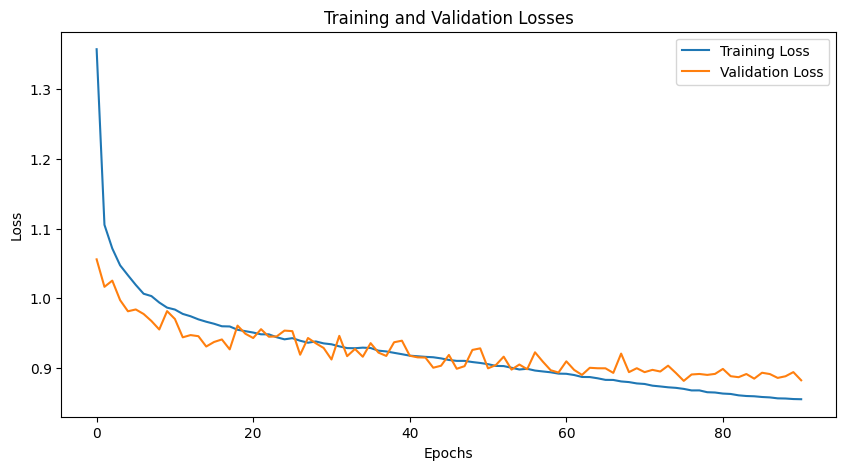

In [23]:

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [14]:
import soundfile as sf

TARGET_FRAMES = 256

# Load the best model for evaluation
CHECKPOINT_PATH = "best_checkpoint.pth"
model.load_state_dict(torch.load(CHECKPOINT_PATH)['model_state_dict'])


# Load a test file
test_noisy, _ = lib.load(
    r'C:\Users\dell\Downloads\FYP DENOIZER\input.wav',
    sr=16000, mono=True
)

# Get the FULL stft of original audio (for phase)
full_mag, full_phase = compute_stft(test_noisy)
original_frames = full_mag.shape[1]   # actual number of frames

# Preprocess for model (pads/trims to 256)
model_input, _ = preprocess_audio(test_noisy, TARGET_FRAMES)
model_input = torch.tensor(model_input).float().unsqueeze(0).to(device)

# Run through model
model.eval()
with torch.no_grad():
    enhanced, mask = model(model_input)

# Convert back — trim or pad enhanced output to match original phase length
enhanced_np = enhanced.squeeze().cpu().numpy()  # (257, 256)

# ← Fixed: match enhanced magnitude size to original phase size
if original_frames <= TARGET_FRAMES:
    enhanced_mag = enhanced_np[:, :original_frames]   # trim to original
else:
    pad = original_frames - TARGET_FRAMES
    enhanced_mag = np.pad(enhanced_np, ((0,0),(0,pad)), mode='constant')  # pad

# Reverse log magnitude
mag = np.exp(enhanced_mag) - 1e-8

# Reconstruct using original phase
reconstructed = compute_istft(mag, full_phase)

# Save both files
sf.write("noisy_original.wav", test_noisy, 16000)
sf.write("enhanced_output sachetan.wav", reconstructed, 16000)
print(f" Saved both files!")
print(f"   Original frames: {original_frames}, Enhanced frames: {enhanced_mag.shape[1]}")

C:\Users\dell\AppData\Local\Temp\ipykernel_2744\3274178281.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH)['model_state

 Saved both files!
   Original frames: 508, Enhanced frames: 508


### Waveform Comparison: Noisy vs. Enhanced

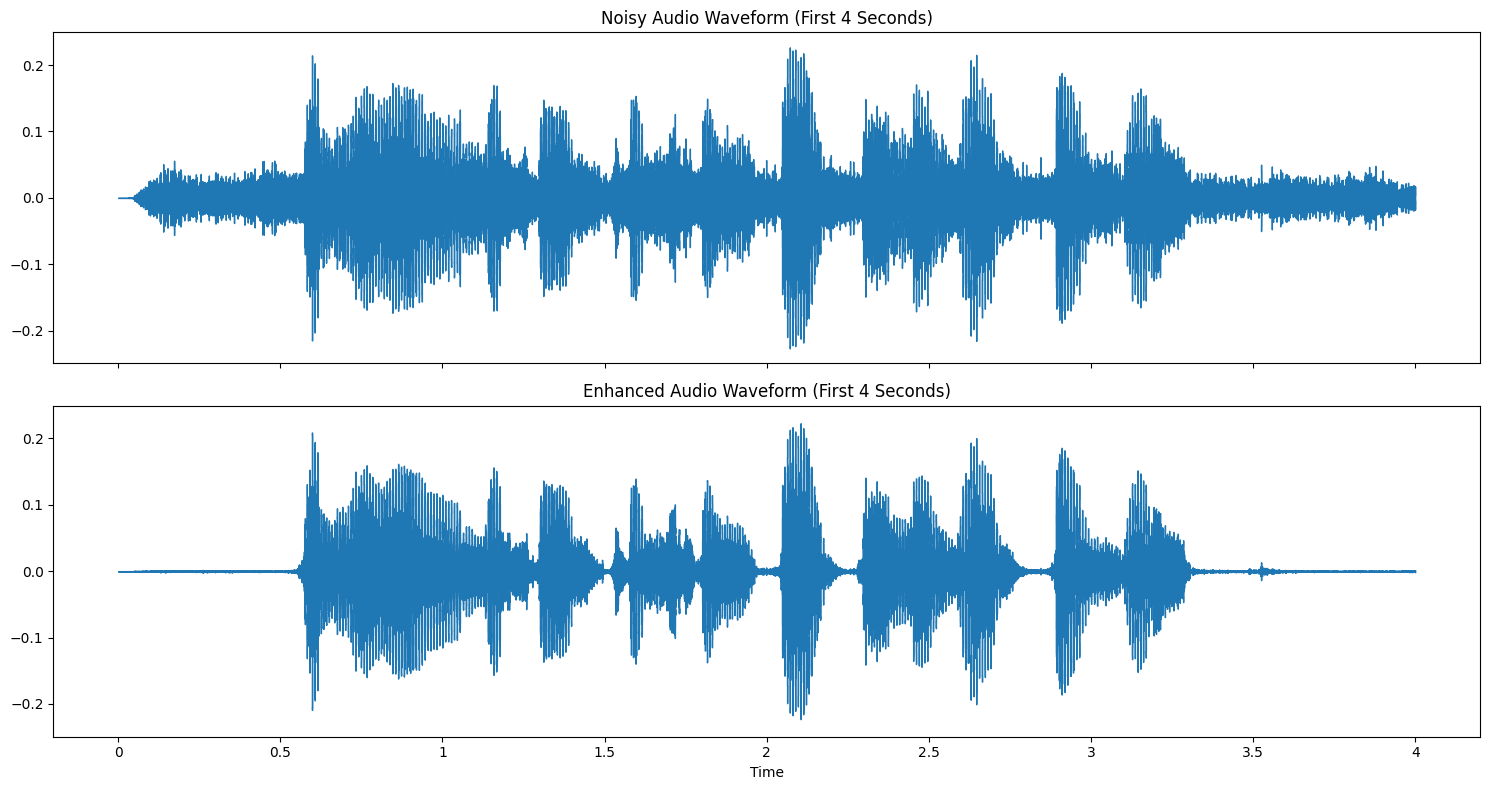

In [16]:

# Waveform Visualization
fig, ax = plt.subplots(nrows=2, figsize=(15, 8), sharex=True, sharey=True)

# Determine the 4-second clip length in samples
clip_duration_samples = 4 * 16000

# Display the clipped waveforms
lib.display.waveshow(test_noisy[:clip_duration_samples], sr=16000, ax=ax[0])
ax[0].set_title('Noisy Audio Waveform (First 4 Seconds)')
ax[0].set_xlabel("")

lib.display.waveshow(reconstructed[:clip_duration_samples], sr=16000, ax=ax[1])
ax[1].set_title('Enhanced Audio Waveform (First 4 Seconds)')

plt.tight_layout()
plt.show()


In [24]:
import torch

def si_snr(estimate, target, eps=1e-8):
    # Zero mean
    target = target - torch.mean(target, dim=-1, keepdim=True)
    estimate = estimate - torch.mean(estimate, dim=-1, keepdim=True)
    
    # SI-SNR
    dot = torch.sum(target * estimate, dim=-1, keepdim=True)
    s_target_energy = torch.sum(target ** 2, dim=-1, keepdim=True) + eps
    s_target = (dot / s_target_energy) * target
    
    e_noise = estimate - s_target
    
    si_snr_val = 10 * torch.log10(
        torch.sum(s_target ** 2, dim=-1) / (torch.sum(e_noise ** 2, dim=-1) + eps)
    )
    
    return si_snr_val.mean()

In [27]:
from pesq import pesq
from pystoi import stoi

# Load the best model for evaluation
model.load_state_dict(torch.load(CHECKPOINT_PATH)['model_state_dict'])
model.eval()

# Create a list of test files
test_filenames = sorted(os.listdir(noisy_test_set))

# Initialize lists to store scores
pesq_scores_noisy, stoi_scores_noisy, sisnr_scores_noisy = [], [], []
pesq_scores_enhanced, stoi_scores_enhanced, sisnr_scores_enhanced = [], [], []

print("Running evaluation on the test set...")

for fname in tqdm(test_filenames):
    # Load noisy and clean audio
    noisy_path = os.path.join(noisy_test_set, fname)
    clean_path = os.path.join(clean_test_set, fname)
    
    test_noisy, sr = lib.load(noisy_path, sr=SAMPLE_RATE, mono=True)
    test_clean, _ = lib.load(clean_path, sr=SAMPLE_RATE, mono=True)

    # --- Get Enhanced Audio ---
    full_mag, full_phase = compute_stft(test_noisy)
    original_frames = full_mag.shape[1]
    
    model_input, _ = preprocess_audio(test_noisy, TARGET_FRAMES)
    model_input = torch.tensor(model_input).float().unsqueeze(0).to(device)

    with torch.no_grad():
        enhanced_spec, _ = model(model_input)

    enhanced_np = enhanced_spec.squeeze().cpu().numpy()

    if original_frames <= TARGET_FRAMES:
        enhanced_mag = enhanced_np[:, :original_frames]
    else:
        pad = original_frames - TARGET_FRAMES
        enhanced_mag = np.pad(enhanced_np, ((0,0),(0,pad)), mode='constant')

    mag = np.exp(enhanced_mag) - EPSILON
    reconstructed_audio = compute_istft(mag, full_phase)
    
    # Ensure all audio is the same length for comparison
    min_len = min(len(test_clean), len(reconstructed_audio), len(test_noisy))
    
    # Skip files that are too short for PESQ
    if min_len < SAMPLE_RATE / 4:
        print(f"Skipping {fname} because it is too short ({min_len} samples).")
        continue

    test_clean = test_clean[:min_len]
    reconstructed_audio = reconstructed_audio[:min_len]
    test_noisy = test_noisy[:min_len]

    # --- Calculate Metrics ---
    # PESQ (requires 16kHz or 8kHz sample rate)
    pesq_noisy = pesq(SAMPLE_RATE, test_clean, test_noisy, 'wb')
    pesq_enhanced = pesq(SAMPLE_RATE, test_clean, reconstructed_audio, 'wb')
    
    # STOI
    stoi_noisy = stoi(test_clean, test_noisy, SAMPLE_RATE, extended=False)
    stoi_enhanced = stoi(test_clean, reconstructed_audio, SAMPLE_RATE, extended=False)
    
    # SI-SNR
    sisnr_noisy = si_snr(
        torch.tensor(test_noisy).unsqueeze(0),
        torch.tensor(test_clean).unsqueeze(0)
    )
    sisnr_enhanced = si_snr(
        torch.tensor(reconstructed_audio).unsqueeze(0),
        torch.tensor(test_clean).unsqueeze(0)
    )

    # Append scores
    pesq_scores_noisy.append(pesq_noisy)
    stoi_scores_noisy.append(stoi_noisy)
    sisnr_scores_noisy.append(sisnr_noisy.item())
    
    pesq_scores_enhanced.append(pesq_enhanced)
    stoi_scores_enhanced.append(stoi_enhanced)
    sisnr_scores_enhanced.append(sisnr_enhanced.item())

# --- Calculate and Print Average Scores ---
print("\n--- Evaluation Results ---")
print(f"Metrics on {len(pesq_scores_enhanced)} test files.") # Use a list that gets appended to
print("\nNoisy Audio Averages:")
print(f"  PESQ: {np.mean(pesq_scores_noisy):.2f}")
print(f"  STOI: {np.mean(stoi_scores_noisy):.2f}")
print(f"  SI-SNR: {np.mean(sisnr_scores_noisy):.2f} dB")

print("\nEnhanced Audio Averages:")
print(f"  PESQ: {np.mean(pesq_scores_enhanced):.2f}")
print(f"  STOI: {np.mean(stoi_scores_enhanced):.2f}")
print(f"  SI-SNR: {np.mean(sisnr_scores_enhanced):.2f} dB")
print("--------------------------")

C:\Users\dell\AppData\Local\Temp\ipykernel_27424\3966264623.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH)['model_stat

Running evaluation on the test set...


100%|██████████| 824/824 [03:16<00:00,  4.20it/s]


--- Evaluation Results ---
Metrics on 824 test files.

Noisy Audio Averages:
  PESQ: 1.97
  STOI: 0.92
  SI-SNR: 8.46 dB

Enhanced Audio Averages:
  PESQ: 2.40
  STOI: 0.94
  SI-SNR: 7.19 dB
--------------------------
